# Minnit 18 Analysis

## Imports and Setup

In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
from fermipy.gtanalysis import GTAnalysis
from fermipy.plotting import ROIPlotter, SEDPlotter

In [29]:
# Inputs
source_name = "Minniti18"
config_file = "/Users/maomao/sfsu_research/minniti/configs/minniti18_config.yaml"

index = 2.0
glon = 359.665
glat = 3.637

# Zooming factor, None = full ROI
zoom = 4

In [36]:
# Initialize and setup
prefix = f"{source_name}_dedicated"
model_name = f"Model_{source_name}_dedicated"
tsmap_model = {
    "Index": index,
    "SpatialModel": "PointSource",
}

added_source_model = {
    "glon": glon,
    "glat": glat,
    "SpectrumType": "PowerLaw",
    "Index": index,
    "Scale": 1000,
    "Prefactor": 1e-13,
    "SpatialModel": "PointSource",
}
gta = GTAnalysis(
    config_file,
    logging={"verbosity": 3},
)
gta.setup()

2026-07-22 20:50:23 INFO    GTAnalysis.__init__(): 
--------------------------------------------------------------------------------
fermipy version 1.4.0 
ScienceTools version 2.2.0
2026-07-22 20:50:23 INFO    GTAnalysis.setup(): Running setup.
2026-07-22 20:50:23 INFO    GTBinnedAnalysis.setup(): Running setup for component 00
2026-07-22 20:50:23 INFO    GTBinnedAnalysis._select_data(): Skipping data selection.
2026-07-22 20:50:23 INFO    GTBinnedAnalysis._create_ltcube(): Skipping LT Cube.
2026-07-22 20:50:24 INFO    GTBinnedAnalysis._create_expcube(): Skipping gtexpcube.
Set MJD-OBS to 54682.655283 from DATE-OBS.
Set MJD-END to 61206.765082 from DATE-END'. [astropy.wcs.wcs]
2026-07-22 20:50:24 INFO    GTBinnedAnalysis._create_srcmaps(): Skipping gtsrcmaps.
2026-07-22 20:50:24 INFO    GTBinnedAnalysis.setup(): Finished setup for component 00
2026-07-22 20:50:24 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2026-07-22 20:50:26 INFO    G

## Optimize and Fit

In [37]:
# Optimize
opt_result = gta.optimize()
print(opt_result)

2026-07-22 20:50:26 INFO    GTAnalysis.optimize(): Starting


Joint fit  ['galdiff', 'isodiff', '4FGL J1745.6-2859', '4FGL J1734.5-2818', '4FGL J1741.6-2730']


/opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/fermipy/utils.py:785: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  spline = UnivariateSpline(x, y, k=2,


Fitting shape galdiff TS: 138687.870
Fitting shape 4FGL J1731.6-3002 TS:    360.917
Fitting shape 4FGL J1716.7-2808 TS:    270.649
Fitting shape 4FGL J1740.7-2640 TS:    163.495
Fitting shape 4FGL J1739.7-2836 TS:    115.972
Fitting shape 4FGL J1739.3-2531 TS:    108.974
Fitting shape 4FGL J1734.5-2818 TS:     77.140
Fitting shape 4FGL J1731.9-2719 TS:     77.080
Fitting shape 4FGL J1736.3-2929 TS:     75.710
Fitting shape 4FGL J1737.1-2901 TS:     70.860
Fitting shape 4FGL J1729.4-2646 TS:     69.608
Fitting shape 4FGL J1739.2-2717 TS:     66.414
Fitting shape 4FGL J1733.5-2950 TS:     64.381
Fitting shape 4FGL J1745.6-2859 TS:     63.812
Fitting shape 4FGL J1732.0-2659 TS:     57.466
Fitting shape 4FGL J1741.6-2730 TS:     54.730
Fitting shape 4FGL J1732.7-2559 TS:     52.925
Fitting shape 4FGL J1726.0-2843 TS:     52.420
Fitting shape 4FGL J1737.2-2808 TS:     51.460
Fitting shape 4FGL J1726.2-2903 TS:     50.781
Fitting shape 4FGL J1733.2-2915 TS:     49.444
Fitting shape 4FGL J172

2026-07-22 20:53:48 INFO    GTAnalysis.optimize(): Finished
2026-07-22 20:53:48 INFO    GTAnalysis.optimize(): LogLike: 1390466.767805 Delta-LogLike: 82.646161
2026-07-22 20:53:48 INFO    GTAnalysis.optimize(): Execution time: 201.52 s


{'loglike0': 1390384.1216443444, 'loglike1': 1390466.7678051074, 'dloglike': 82.6461607629899, 'config': {'npred_threshold': 1.0, 'npred_frac': 0.95, 'shape_ts_threshold': 25.0, 'max_free_sources': 5, 'skip': [], 'optimizer': {'optimizer': 'NEWMINUIT', 'tol': 0.001, 'max_iter': 100, 'init_lambda': 0.0001, 'retries': 3, 'min_fit_quality': 2, 'verbosity': 0}}}


In [38]:
# Baseline background fit
gta.free_sources(free=False)
gta.free_source('galdiff')
gta.free_source('isodiff')

gta.free_sources(minmax_ts=[25,None], pars="norm",free=True)
gta.fit()

2026-07-22 20:53:48 INFO    GTAnalysis.free_source(): Freeing parameters for galdiff               : ['Prefactor', 'Index']
2026-07-22 20:53:48 INFO    GTAnalysis.free_source(): Freeing parameters for isodiff               : ['Normalization']
2026-07-22 20:53:48 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1731.9-2719     : ['Prefactor']
2026-07-22 20:53:48 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1732.0-2659     : ['norm']
2026-07-22 20:53:48 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1729.4-2646     : ['norm']
2026-07-22 20:53:48 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1731.9-2800     : ['Prefactor']
2026-07-22 20:53:48 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1726.8-2659     : ['Prefactor']
2026-07-22 20:53:48 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1729.4-2831     : ['norm']
2026-07-22 20:53:48 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL 

{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 8.506838398054242,
 'edm': 0.00013607503672083074,
 'loglike': 1390475.2746435055,
 'covariance': array([[ 6.64196074e-03,  4.00256576e-04,  7.07656943e-05, ...,
          3.80869984e-05,  7.88951038e-06, -3.55797056e-03],
        [ 4.00256576e-04,  2.83078730e-02,  9.10169966e-04, ...,
          1.06782573e-04,  2.53499433e-06, -1.14933135e-02],
        [ 7.07656943e-05,  9.10169966e-04,  8.21999372e-03, ...,
         -1.16234299e-05, -7.58275020e-06, -2.18191027e-03],
        ...,
        [ 3.80869984e-05,  1.06782573e-04, -1.16234299e-05, ...,
          5.10800446e-05,  8.25208677e-06, -1.69151826e-03],
        [ 7.88951038e-06,  2.53499433e-06, -7.58275020e-06, ...,
          8.25208677e-06,  6.66429863e-06, -2.95113085e-04],
        [-3.55797056e-03, -1.14933135e-02, -2.18191027e-03, ...,
         -1.69151826e-03, -2.95113085e-04,  7.17644234e-02]]),
 'correlation': array([[ 1.        ,  0.02919018,  0.0095772

In [75]:
gta.print_model()

2026-07-27 18:38:41 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1731.9-2719      0.242   0.442  3.47e-06   2.31     60.31      1389.3    *
4FGL J1732.0-2659      0.383   0.525  2.54e-06   2.37     48.12      1060.0    *
4FGL J1729.4-2646      0.590   0.294  2.15e-06   2.69     51.47       893.2    *
4FGL J1731.9-2800      0.775   0.516  2.57e-06   2.56     29.96      1348.0    *
4FGL J1726.8-2659      0.936   0.644  2.01e-06   2.47     25.92       954.4    *
4FGL J1729.4-2831      1.288   0.535  1.98e-06   3.99     32.42      1109.1    *
4FGL J1734.5-2818      1.316   0.392  3.01e-06   3.41     64.35      1466.9    *
4FGL J1732.7-2559      1.360   0.278  2.44e-06   2.94     32.19      1384.1    *
4FGL J1736.1-2628      1.429   0.686  2.42e-06   3.19     32.63      1365.1    *
4FGL J1733.0-2837      1.438   2.185  3.34e-06   2.50 

In [76]:
gta.free_sources(distance=3,pars='norm',free=True)
gta.fit()

2026-07-27 18:39:24 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1730.3-2913     : ['norm']
2026-07-27 18:39:24 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1740.6-2808     : ['Prefactor']
2026-07-27 18:39:24 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1729.9-2952     : ['norm']
2026-07-27 18:39:24 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1740.4-2850     : ['norm']
2026-07-27 18:39:24 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1738.2-2510     : ['norm']
2026-07-27 18:39:24 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1733.6-2431     : ['norm']
2026-07-27 18:39:24 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1742.5-2833     : ['norm']
2026-07-27 18:39:24 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1738.1-2453     : ['norm']
2026-07-27 18:39:24 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1739.5-2929     : ['norm']
2026-

{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 1.1924791475757957,
 'edm': 0.00023607807817890999,
 'loglike': 1390476.467122652,
 'covariance': array([[ 6.65678261e-03,  4.87985020e-04,  1.01607451e-04, ...,
          3.63991578e-05,  5.17150674e-06, -3.66827410e-03],
        [ 4.87985020e-04,  2.85763901e-02,  1.02523625e-03, ...,
          9.95665916e-05, -8.65547072e-06, -1.18772298e-02],
        [ 1.01607451e-04,  1.02523625e-03,  8.25741599e-03, ...,
         -1.79586506e-05, -1.14050807e-05, -2.21266311e-03],
        ...,
        [ 3.63991578e-05,  9.95665916e-05, -1.79586506e-05, ...,
          5.56121416e-05,  8.46419666e-06, -1.80664469e-03],
        [ 5.17150674e-06, -8.65547072e-06, -1.14050807e-05, ...,
          8.46419666e-06,  7.35795165e-06, -2.82658664e-04],
        [-3.66827410e-03, -1.18772298e-02, -2.21266311e-03, ...,
         -1.80664469e-03, -2.82658664e-04,  7.57500880e-02]]),
 'correlation': array([[ 1.        ,  0.03538104,  0.0137047

In [77]:
gta.write_roi('fit_init_norm_only')

2026-07-27 18:40:32 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_init_norm_only_00.xml...
2026-07-27 18:40:32 INFO    GTAnalysis.write_fits(): Writing /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_init_norm_only.fits...
2026-07-27 18:40:39 INFO    GTAnalysis.write_roi(): Writing /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_init_norm_only.npy...


In [78]:
gta.free_sources(distance=1,minmax_ts=[25,None],pars='shape',free=True)
gta.fit()

2026-07-27 18:41:27 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1731.9-2719     : ['Index']
2026-07-27 18:41:27 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1732.0-2659     : ['alpha', 'beta']
2026-07-27 18:41:27 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1729.4-2646     : ['alpha', 'beta']
2026-07-27 18:41:27 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1731.9-2800     : ['Index']
2026-07-27 18:41:27 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1726.8-2659     : ['Index']
2026-07-27 18:41:27 INFO    GTAnalysis.fit(): Starting fit.
/opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/fermipy/utils.py:785: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)

{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 0.21695063193328679,
 'edm': 0.0005307137715599639,
 'loglike': 1390476.684073284,
 'covariance': array([[ 6.67092734e-03,  5.26918301e-04,  1.26342210e-04, ...,
          3.58961561e-05,  1.72104549e-06, -3.82727460e-03],
        [ 5.26918301e-04,  2.86665145e-02,  1.07127507e-03, ...,
          9.61340839e-05, -1.66144604e-05, -1.20600055e-02],
        [ 1.26342210e-04,  1.07127507e-03,  8.27371910e-03, ...,
         -1.87423472e-05, -1.50601809e-05, -2.37698387e-03],
        ...,
        [ 3.58961561e-05,  9.61340839e-05, -1.87423472e-05, ...,
          5.57578443e-05,  8.41898965e-06, -1.80813602e-03],
        [ 1.72104549e-06, -1.66144604e-05, -1.50601809e-05, ...,
          8.41898965e-06,  7.84253426e-06, -2.55578841e-04],
        [-3.82727460e-03, -1.20600055e-02, -2.37698387e-03, ...,
         -1.80813602e-03, -2.55578841e-04,  7.70844296e-02]]),
 'correlation': array([[ 1.        ,  0.03810331,  0.0170061

In [96]:
gta.load_roi('fit_init')
gta.free_sources(distance=1.4,pars='shape',free=True)
gta.fit()

2026-07-27 19:07:43 INFO    GTAnalysis.load_roi(): Loading ROI file: /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_init.npy
2026-07-27 19:07:43 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2026-07-27 19:07:46 INFO    GTAnalysis.load_roi(): Finished Loading ROI
2026-07-27 19:07:46 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1729.4-2831     : ['alpha', 'beta']
2026-07-27 19:07:46 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1734.5-2818     : ['alpha', 'beta']
2026-07-27 19:07:46 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1732.7-2559     : ['alpha', 'beta']
2026-07-27 19:07:46 INFO    GTAnalysis.fit(): Starting fit.
/opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/fermipy/utils.py:785: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too sm

{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 1.3067092937417328,
 'edm': 0.001138551151823329,
 'loglike': 1390477.9907825766,
 'covariance': array([[ 6.66671450e-03,  5.61448072e-04,  1.32685535e-04, ...,
          3.79966416e-05,  8.33215966e-09, -3.95396205e-03],
        [ 5.61448072e-04,  2.86613604e-02,  1.08972508e-03, ...,
          1.01990175e-04, -2.30440141e-05, -1.24505809e-02],
        [ 1.32685535e-04,  1.08972508e-03,  8.29229010e-03, ...,
         -1.71262803e-05, -1.62308032e-05, -2.46265164e-03],
        ...,
        [ 3.79966416e-05,  1.01990175e-04, -1.71262803e-05, ...,
          5.67861210e-05,  8.30720536e-06, -1.85161875e-03],
        [ 8.33215966e-09, -2.30440141e-05, -1.62308032e-05, ...,
          8.30720536e-06,  8.25966655e-06, -2.40136870e-04],
        [-3.95396205e-03, -1.24505809e-02, -2.46265164e-03, ...,
         -1.85161875e-03, -2.40136870e-04,  7.92358877e-02]]),
 'correlation': array([[ 1.00000000e+00,  4.06167589e-02,  1.

In [97]:
gta.write_roi('fit_init')

2026-07-27 19:09:06 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_init_00.xml...
2026-07-27 19:09:06 INFO    GTAnalysis.write_fits(): Writing /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_init.fits...
2026-07-27 19:09:14 INFO    GTAnalysis.write_roi(): Writing /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_init.npy...


In [ ]:
gta.load_roi('fit_init')

## Initial Maps

2026-07-23 19:17:15 INFO    GTAnalysis.load_roi(): Loading ROI file: /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_init_norm_only.npy
2026-07-23 19:17:15 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2026-07-23 19:17:18 INFO    GTAnalysis.load_roi(): Finished Loading ROI
2026-07-23 19:17:18 INFO    GTAnalysis.tsmap(): Generating TS map
2026-07-23 19:17:19 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2026-07-23 19:17:20 INFO    GTAnalysis.tsmap(): Finished TS map
2026-07-23 19:17:26 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/pointsource_powerlaw_2.00_tsmap.npy
2026-07-23 19:17:26 INFO    GTAnalysis.tsmap(): Execution time: 7.45 s


<Figure size 640x480 with 0 Axes>

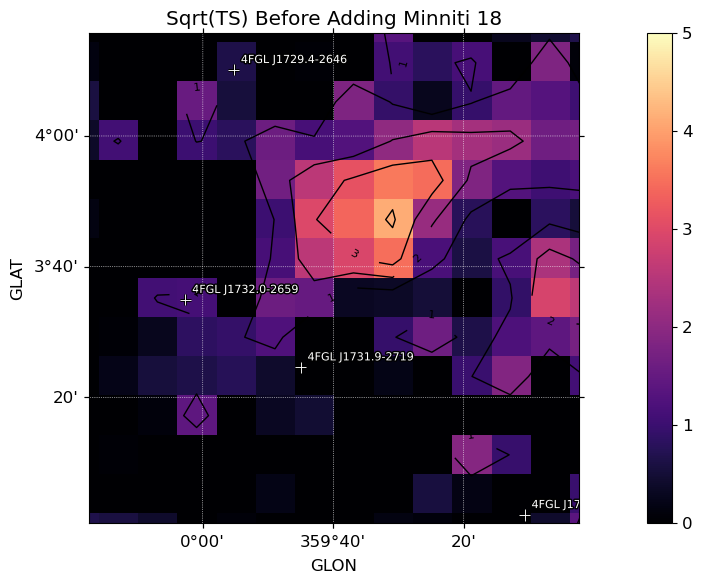

In [45]:
# Compute TS map of baseline model
gta.load_roi('fit_init_norm_only')
tsmap_before = gta.tsmap(make_plots=False, write_fits=True, write_npy=True)

plt.clf()
fig = plt.figure(figsize=(8, 6))

plotter = ROIPlotter(
    tsmap_before["sqrt_ts"],
    roi=gta.roi,
)

plotter.plot(
    levels=[1, 2, 3, 4, 5],
    vmin=0,
    vmax=5,
    cmap="magma",
)

if zoom is not None:
    plotter.zoom(zoom)

plt.title("Sqrt(TS) Before Adding Minniti 18")
plt.tight_layout()
plt.savefig(
    "/Users/maomao/sfsu_research/minniti/results/standard_diffuse/maps/minniti18_tsmap_before.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Add Minniti 18

In [12]:
from astropy.coordinates import SkyCoord
import astropy.units as u

In [ ]:
gta.load_roi("fit_init_norm_only")

# Add Minniti 18
gta.add_source(source_name,added_source_model,free=True,save_source_maps=False)

gta.optimize()

# Freeze all sources before fit
for src in gta.roi.sources:
    gta.free_source(src.name, free=False)
    
gta.free_source("galdiff")
gta.free_source("isodiff")

# Free nearby source norms
gta.free_sources(minmax_ts=[25,None],pars="norm")
gta.fit()

2026-07-22 21:26:07 INFO    GTAnalysis.load_roi(): Loading ROI file: /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_init_norm_only.npy
2026-07-22 21:26:07 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2026-07-22 21:26:09 INFO    GTAnalysis.load_roi(): Finished Loading ROI
2026-07-22 21:26:09 INFO    GTAnalysis.add_source(): Adding source Minniti18
2026-07-22 21:26:10 INFO    GTAnalysis.optimize(): Starting


Joint fit  ['galdiff', 'isodiff', '4FGL J1745.6-2859', '4FGL J1737.1-2901', '4FGL J1746.4-2852']


/opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/fermipy/utils.py:785: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  spline = UnivariateSpline(x, y, k=2,


Fitting shape galdiff TS: 103580.376
Fitting shape 4FGL J1731.6-3002 TS:    329.411
Fitting shape 4FGL J1716.7-2808 TS:    232.091
Fitting shape 4FGL J1740.7-2640 TS:    132.260
Fitting shape 4FGL J1739.7-2836 TS:     90.656
Fitting shape 4FGL J1739.3-2531 TS:     75.500
Fitting shape 4FGL J1745.6-2859 TS:     74.573
Fitting shape 4FGL J1736.3-2929 TS:     68.391
Fitting shape 4FGL J1734.5-2818 TS:     68.020
Fitting shape 4FGL J1733.5-2950 TS:     58.064
Fitting shape 4FGL J1731.9-2719 TS:     54.555
Fitting shape 4FGL J1737.1-2901 TS:     52.303
Fitting shape 4FGL J1729.4-2646 TS:     51.888
Fitting shape 4FGL J1732.0-2659 TS:     48.773
Fitting shape 4FGL J1733.0-2837 TS:     48.652
Fitting shape 4FGL J1741.6-2730 TS:     48.519
Fitting shape 4FGL J1739.2-2717 TS:     45.205
Fitting shape 4FGL J1726.0-2843 TS:     42.749
Fitting shape 4FGL J1735.4-2944 TS:     39.005
Fitting shape 4FGL J1726.2-2903 TS:     36.968
Fitting shape 4FGL J1739.2-2732 TS:     36.750
Fitting shape 4FGL J173

2026-07-22 21:29:19 INFO    GTAnalysis.optimize(): Finished
2026-07-22 21:29:19 INFO    GTAnalysis.optimize(): LogLike: 1390493.407686 Delta-LogLike: 11.989556
2026-07-22 21:29:19 INFO    GTAnalysis.optimize(): Execution time: 188.82 s
2026-07-22 21:29:19 INFO    GTAnalysis.free_source(): Fixing parameters for Minniti18             : ['Prefactor']
2026-07-22 21:29:19 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1731.9-2719     : ['Prefactor']
2026-07-22 21:29:19 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1732.0-2659     : ['norm']
2026-07-22 21:29:19 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1729.4-2646     : ['norm']
2026-07-22 21:29:19 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1731.9-2800     : ['Prefactor']
2026-07-22 21:29:19 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1726.8-2659     : ['Prefactor']
2026-07-22 21:29:19 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1729.4-2

{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 0.45123162493109703,
 'edm': 6.324093969606179e-05,
 'loglike': 1390493.8589180973,
 'covariance': array([[ 6.71902133e-03, -1.78419869e-06,  5.17968506e-04, ...,
          3.21315760e-05,  9.79279615e-06, -2.82192382e-03],
        [-1.78419869e-06,  8.86506904e-03, -2.78385944e-03, ...,
         -2.16031449e-05, -1.44409130e-06, -9.77552942e-04],
        [ 5.17968506e-04, -2.78385944e-03,  1.23573658e-01, ...,
         -5.74799707e-06,  2.61234674e-07, -4.86612250e-03],
        ...,
        [ 3.21315760e-05, -2.16031449e-05, -5.74799707e-06, ...,
          5.05782802e-05,  8.18189209e-06, -1.63913630e-03],
        [ 9.79279615e-06, -1.44409130e-06,  2.61234674e-07, ...,
          8.18189209e-06,  6.63049076e-06, -3.02422280e-04],
        [-2.82192382e-03, -9.77552942e-04, -4.86612250e-03, ...,
         -1.63913630e-03, -3.02422280e-04,  6.44128865e-02]]),
 'correlation': array([[ 1.00000000e+00, -2.31179406e-04,  

In [43]:
gta.write_roi("fit_minniti18_norm_only")

2026-07-22 21:31:27 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_minniti18_norm_only_00.xml...
2026-07-22 21:31:27 INFO    GTAnalysis.write_fits(): Writing /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_minniti18_norm_only.fits...
2026-07-22 21:31:34 INFO    GTAnalysis.write_roi(): Writing /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_minniti18_norm_only.npy...


In [21]:
gta.free_sources(distance=3,minmax_ts=[25,None],pars="norm")
gta.fit()

gta.write_roi("fit_minniti18")

gta.free_sources(distance=3,minmax_ts=[25,None],pars="shape")
gta.fit()

2026-07-21 16:17:01 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1733.2-2915     : ['norm']
2026-07-21 16:17:01 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1726.2-2903     : ['norm']
2026-07-21 16:17:01 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1734.6-2912     : ['Prefactor']
2026-07-21 16:17:01 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1737.1-2901     : ['Prefactor']
2026-07-21 16:17:01 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1731.4-2932     : ['Prefactor']
2026-07-21 16:17:01 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1740.7-2640     : ['norm']
2026-07-21 16:17:01 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1739.7-2836     : ['norm']
2026-07-21 16:17:01 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1741.6-2730     : ['norm']
2026-07-21 16:17:01 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1723.1-2859     : ['no

{'fit_quality': 3,
 'fit_status': 156,
 'fit_success': True,
 'dloglike': 0.1605308298021555,
 'edm': 0.0009213296771071088,
 'loglike': 1390498.331026039,
 'covariance': array([[ 1.44793211e-02,  2.06988211e-02,  1.37562401e-02, ...,
         -3.12168061e-05, -3.39899217e-06, -5.34136007e-04],
        [ 2.06988211e-02,  1.93665125e-01, -6.55799357e-02, ...,
          1.94569790e-05, -8.95476243e-05, -6.50600702e-03],
        [ 1.37562401e-02, -6.55799357e-02,  1.53165199e-01, ...,
         -8.08801056e-05,  2.18385267e-05,  5.87988040e-03],
        ...,
        [-3.12168061e-05,  1.94569790e-05, -8.08801056e-05, ...,
          5.28859182e-05,  7.71290982e-06, -1.70606112e-03],
        [-3.39899217e-06, -8.95476243e-05,  2.18385267e-05, ...,
          7.71290982e-06,  8.27886743e-06, -2.44632966e-04],
        [-5.34136007e-04, -6.50600702e-03,  5.87988040e-03, ...,
         -1.70606112e-03, -2.44632966e-04,  6.70970531e-02]]),
 'correlation': array([[ 1.        ,  0.39088212,  0.292109

In [22]:
gta.free_sources(distance=4,minmax_ts=[25,None],pars="norm")
gta.fit()

gta.write_roi("fit_minniti18")

gta.free_sources(distance=4,minmax_ts=[25,None],pars="shape")
gta.fit()

2026-07-21 16:18:15 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1729.9-2403     : ['norm']
2026-07-21 16:18:15 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1716.7-2808     : ['norm']
2026-07-21 16:18:15 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1745.6-2859     : ['norm']
2026-07-21 16:18:15 INFO    GTAnalysis.fit(): Starting fit.
2026-07-21 16:18:58 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   3 Status: 156
2026-07-21 16:18:58 INFO    GTAnalysis.fit(): LogLike:  1390498.368 DeltaLogLike:        0.037 
2026-07-21 16:18:58 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_minniti18_00.xml...
2026-07-21 16:18:58 INFO    GTAnalysis.write_fits(): Writing /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_minniti18.fits...
2026-07-21 16:19:05 INFO    GTAnalysis.write_roi(): Writing /Users/maomao/sfsu_

{'fit_quality': 3,
 'fit_status': 156,
 'fit_success': True,
 'dloglike': 0.36050297040492296,
 'edm': 0.007327294347940135,
 'loglike': 1390498.7281160348,
 'covariance': array([[ 9.44995023e-03,  9.47580037e-04,  4.94340894e-03, ...,
          2.45223579e-06, -1.84239846e-06, -2.01567588e-03],
        [ 9.47580037e-04,  2.33671480e-02, -1.09309617e-02, ...,
          6.59829306e-05, -6.32592809e-05, -7.69317465e-03],
        [ 4.94340894e-03, -1.09309617e-02,  1.57406460e-02, ...,
         -5.86039745e-05,  3.29031967e-05,  5.05167980e-03],
        ...,
        [ 2.45223579e-06,  6.59829306e-05, -5.86039745e-05, ...,
          4.42331072e-05,  7.52698934e-06, -1.36319108e-03],
        [-1.84239846e-06, -6.32592809e-05,  3.29031967e-05, ...,
          7.52698934e-06,  9.20937486e-06, -1.83649490e-04],
        [-2.01567588e-03, -7.69317465e-03,  5.05167980e-03, ...,
         -1.36319108e-03, -1.83649490e-04,  5.73958018e-02]]),
 'correlation': array([[ 1.        ,  0.06376734,  0.40532

In [130]:
gta.load_roi('fit_minniti18_norm_only')
gta.free_sources(distance=3,pars='norm', free=True)
gta.fit()

2026-07-28 19:35:04 INFO    GTAnalysis.load_roi(): Loading ROI file: /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_minniti18_norm_only.npy
2026-07-28 19:35:04 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2026-07-28 19:35:07 INFO    GTAnalysis.load_roi(): Finished Loading ROI
2026-07-28 19:35:07 INFO    GTAnalysis.free_source(): Freeing parameters for Minniti18             : ['Prefactor']
2026-07-28 19:35:07 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1731.6-2904     : ['Prefactor']
2026-07-28 19:35:07 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1730.3-2913     : ['norm']
2026-07-28 19:35:07 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1729.2-2509     : ['norm']
2026-07-28 19:35:07 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1720.6-2653c    : ['Prefactor']
2026-07-28 19:35:07 INFO    GTAnalysis.free_source(): Freeing paramete

{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 0.5101803070865571,
 'edm': 0.00036157451702424273,
 'loglike': 1390493.78581271,
 'covariance': array([[ 6.77347271e-03,  4.64881268e-04,  6.80098154e-05, ...,
          3.23449360e-05,  6.53025606e-06, -3.33069559e-03],
        [ 4.64881268e-04,  2.84046460e-02,  8.64444746e-04, ...,
          9.82009505e-05, -7.34591535e-06, -1.15979339e-02],
        [ 6.80098154e-05,  8.64444746e-04,  8.93915855e-03, ...,
         -2.42234605e-05, -4.97752546e-06, -1.53182105e-03],
        ...,
        [ 3.23449360e-05,  9.82009505e-05, -2.42234605e-05, ...,
          5.56148563e-05,  8.33538339e-06, -1.80346813e-03],
        [ 6.53025606e-06, -7.34591535e-06, -4.97752546e-06, ...,
          8.33538339e-06,  7.33938011e-06, -2.84074976e-04],
        [-3.33069559e-03, -1.15979339e-02, -1.53182105e-03, ...,
         -1.80346813e-03, -2.84074976e-04,  7.47717917e-02]]),
 'correlation': array([[ 1.        ,  0.03351519,  0.00874012

In [138]:
gta.load_roi('fit_minniti18_norm_only')
gta.free_sources(distance=3.2,pars='norm',free=True)
gta.fit()

2026-07-28 20:18:34 INFO    GTAnalysis.load_roi(): Loading ROI file: /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_minniti18_norm_only.npy
2026-07-28 20:18:34 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2026-07-28 20:18:37 INFO    GTAnalysis.load_roi(): Finished Loading ROI
2026-07-28 20:18:37 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1743.5-2616     : ['Prefactor']
2026-07-28 20:18:37 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1724.5-3008     : ['norm']
2026-07-28 20:18:37 INFO    GTAnalysis.fit(): Starting fit.
2026-07-28 20:18:45 ERROR   GTAnalysis._fit_optimizer(): Likelihood optimization failed.
Traceback (most recent call last):
  File "/opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/fermipy/gtanalysis.py", line 2917, in _fit_optimizer
    self.like.fit(**kw)
  File "/opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/fermitools/SummedLike

{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 0.03608703799545765,
 'edm': 0.00023247399537311062,
 'loglike': 1390493.8218997465,
 'covariance': array([[ 6.77691314e-03,  5.06050906e-04,  1.97055262e-05, ...,
          2.93545525e-05,  4.56979105e-06, -3.35184106e-03],
        [ 5.06050906e-04,  2.86811945e-02,  4.91655357e-04, ...,
          7.69106875e-05, -2.23655517e-05, -1.18011992e-02],
        [ 1.97055262e-05,  4.91655357e-04,  9.38920327e-03, ...,
         -2.19475432e-06,  1.23981827e-05, -1.21199520e-03],
        ...,
        [ 2.93545525e-05,  7.69106875e-05, -2.19475432e-06, ...,
          5.73788948e-05,  9.22470107e-06, -1.80020146e-03],
        [ 4.56979105e-06, -2.23655517e-05,  1.23981827e-05, ...,
          9.22470107e-06,  8.03537456e-06, -2.71105502e-04],
        [-3.35184106e-03, -1.18011992e-02, -1.21199520e-03, ...,
         -1.80020146e-03, -2.71105502e-04,  7.52521984e-02]]),
 'correlation': array([[ 1.        ,  0.03629774,  0.00247

In [139]:
gta.write_roi('fit_minniti18_norm_only')

2026-07-28 20:19:46 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_minniti18_norm_only_00.xml...
2026-07-28 20:19:46 INFO    GTAnalysis.write_fits(): Writing /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_minniti18_norm_only.fits...
2026-07-28 20:19:54 INFO    GTAnalysis.write_roi(): Writing /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_minniti18_norm_only.npy...


In [161]:
gta.load_roi('fit_minniti18_norm_only')
gta.free_sources(distance=1,pars='shape',free=True)
gta.fit()

2026-07-28 22:14:51 INFO    GTAnalysis.load_roi(): Loading ROI file: /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_minniti18_norm_only.npy
2026-07-28 22:14:51 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2026-07-28 22:14:54 INFO    GTAnalysis.load_roi(): Finished Loading ROI
2026-07-28 22:14:54 INFO    GTAnalysis.free_source(): Freeing parameters for Minniti18             : ['Index']
2026-07-28 22:14:54 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1731.9-2719     : ['Index']
2026-07-28 22:14:54 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1732.0-2659     : ['alpha', 'beta']
2026-07-28 22:14:54 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1729.4-2646     : ['alpha', 'beta']
2026-07-28 22:14:54 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1731.9-2800     : ['Index']
2026-07-28 22:14:54 INFO    GTAnalysis.free_source(): Freeing pa

{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 2.416386614087969,
 'edm': 0.00048230244493366716,
 'loglike': 1390496.2382863602,
 'covariance': array([[ 6.79546347e-03,  5.54025576e-04,  2.73471206e-05, ...,
          2.80866203e-05,  9.16221444e-07, -3.50747103e-03],
        [ 5.54025576e-04,  2.88426768e-02,  5.06889485e-04, ...,
          7.18244702e-05, -3.24387897e-05, -1.20793540e-02],
        [ 2.73471206e-05,  5.06889485e-04,  9.39365448e-03, ...,
         -2.61319892e-06,  1.11279816e-05, -1.26537058e-03],
        ...,
        [ 2.80866203e-05,  7.18244702e-05, -2.61319892e-06, ...,
          5.78713639e-05,  9.37900551e-06, -1.80298183e-03],
        [ 9.16221444e-07, -3.24387897e-05,  1.11279816e-05, ...,
          9.37900551e-06,  8.64357538e-06, -2.43493749e-04],
        [-3.50747103e-03, -1.20793540e-02, -1.26537058e-03, ...,
         -1.80298183e-03, -2.43493749e-04,  7.67366980e-02]]),
 'correlation': array([[ 1.        ,  0.03957332,  0.0034228

In [166]:
gta.load_roi('fit_minniti18')
gta.free_sources(distance=1.3,pars='shape',free=True)
gta.fit()

2026-07-28 22:21:07 INFO    GTAnalysis.load_roi(): Loading ROI file: /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_minniti18.npy
2026-07-28 22:21:07 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2026-07-28 22:21:10 INFO    GTAnalysis.load_roi(): Finished Loading ROI
2026-07-28 22:21:10 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1729.4-2831     : ['alpha', 'beta']
2026-07-28 22:21:10 INFO    GTAnalysis.fit(): Starting fit.
2026-07-28 22:21:20 ERROR   GTAnalysis._fit_optimizer(): Likelihood optimization failed.
Traceback (most recent call last):
  File "/opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/fermipy/gtanalysis.py", line 2917, in _fit_optimizer
    self.like.fit(**kw)
  File "/opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/fermitools/SummedLikelihood.py", line 94, in fit
    errors = self._errors(optimizer, verbosity, tol, covar=covar,
  File "/opt/anaconda3

{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 0.09440657519735396,
 'edm': 0.00047726794034884054,
 'loglike': 1390496.3326929365,
 'covariance': array([[ 6.79468233e-03,  5.60971688e-04,  3.00465389e-05, ...,
          2.83213656e-05,  7.34370540e-07, -3.52850338e-03],
        [ 5.60971688e-04,  2.88389323e-02,  5.15737668e-04, ...,
          7.17074427e-05, -3.34555069e-05, -1.21228160e-02],
        [ 3.00465389e-05,  5.15737668e-04,  9.39518240e-03, ...,
         -2.40699926e-06,  1.08047072e-05, -1.28923737e-03],
        ...,
        [ 2.83213656e-05,  7.17074427e-05, -2.40699926e-06, ...,
          5.83486728e-05,  9.59420330e-06, -1.81765943e-03],
        [ 7.34370540e-07, -3.34555069e-05,  1.08047072e-05, ...,
          9.59420330e-06,  8.77281064e-06, -2.47985734e-04],
        [-3.52850338e-03, -1.21228160e-02, -1.28923737e-03, ...,
         -1.81765943e-03, -2.47985734e-04,  7.72997141e-02]]),
 'correlation': array([[ 1.        ,  0.04007438,  0.00376

In [167]:
gta.write_roi('fit_minniti18')

2026-07-28 22:23:12 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_minniti18_00.xml...
2026-07-28 22:23:12 INFO    GTAnalysis.write_fits(): Writing /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_minniti18.fits...
2026-07-28 22:23:19 INFO    GTAnalysis.write_roi(): Writing /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_minniti18.npy...


2026-07-23 19:23:46 INFO    GTAnalysis.load_roi(): Loading ROI file: /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/fit_minniti18_norm_only.npy
2026-07-23 19:23:46 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2026-07-23 19:23:49 INFO    GTAnalysis.load_roi(): Finished Loading ROI
2026-07-23 19:23:49 INFO    GTAnalysis.tsmap(): Generating TS map
2026-07-23 19:23:49 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2026-07-23 19:23:50 INFO    GTAnalysis.tsmap(): Finished TS map
2026-07-23 19:23:57 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/maomao/sfsu_research/minniti/results/standard_diffuse/per_target/Minniti18/pointsource_powerlaw_2.00_tsmap.npy
2026-07-23 19:23:57 INFO    GTAnalysis.tsmap(): Execution time: 7.59 s


<Figure size 640x480 with 0 Axes>

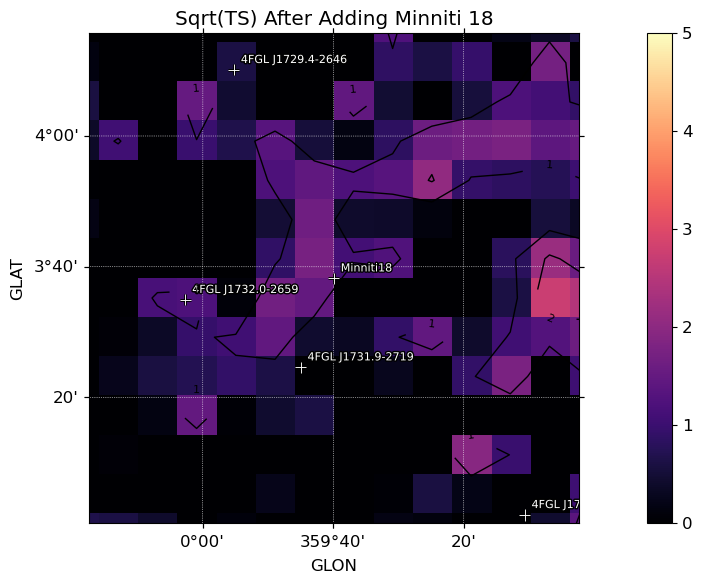

In [46]:
# TS maps with Minniti 18
gta.load_roi('fit_minniti18_norm_only')
tsmap_after = gta.tsmap(make_plots=False, write_fits=True, write_npy=True)

plt.clf()
fig = plt.figure(figsize=(8, 6))

plotter = ROIPlotter(
    tsmap_after["sqrt_ts"],
    roi=gta.roi,
)

plotter.plot(
    levels=[1, 2, 3, 4, 5],
    vmin=0,
    vmax=5,
    cmap="magma",
)

if zoom is not None:
    plotter.zoom(zoom)

plt.title("Sqrt(TS) After Adding Minniti 18")
plt.tight_layout()
plt.savefig(
    "/Users/maomao/sfsu_research/minniti/results/standard_diffuse/maps/minniti18_tsmap_after.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [47]:
gta.print_model()

2026-07-23 19:28:02 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
Minniti18              0.000   2.688  1.99e-06   2.00     20.27       448.2     
4FGL J1731.9-2719      0.242   0.350  2.74e-06   2.30     39.94      1076.0    *
4FGL J1732.0-2659      0.383   0.486  2.45e-06   2.37     43.60      1033.9    *
4FGL J1729.4-2646      0.590   0.279  1.98e-06   2.64     47.63       781.9    *
4FGL J1731.9-2800      0.775   0.514  2.64e-06   2.60     31.39      1442.0    *
4FGL J1726.8-2659      0.936   0.627  1.95e-06   2.39     24.66       849.0    *
4FGL J1729.4-2831      1.288   0.585   1.7e-06   4.47     31.59       876.4    *
4FGL J1734.5-2818      1.316   0.416  2.64e-06   3.76     61.26      1220.3    *
4FGL J1732.7-2559      1.360   0.261   2.4e-06   2.94     30.44      1385.8    *
4FGL J1736.1-2628      1.429   0.673  2.39e-06   3.20 

## Localize Source

In [44]:
# Localize Minniti 18
gta.free_sources(free=False)
loc = gta.localize('Minniti18',free_radius=3.0,update=True,make_plots=True)

# Print results
print("="*60)
print("Localization Results for Minniti18")
print("="*60)

print(f"New glon      : {loc['glon']:.5f}")
print(f"New glat      : {loc['glat']:.5f}")
print(f"Position offset : {loc['pos_offset']:.5f} deg")
print(f"68% radius      : {loc['pos_r68']:.5f} deg")
print(f"95% radius      : {loc['pos_r95']:.5f} deg")

2026-07-22 21:37:00 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1731.9-2719     : ['Prefactor']
2026-07-22 21:37:00 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1732.0-2659     : ['norm']
2026-07-22 21:37:00 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1729.4-2646     : ['norm']
2026-07-22 21:37:00 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1731.9-2800     : ['Prefactor']
2026-07-22 21:37:00 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1726.8-2659     : ['Prefactor']
2026-07-22 21:37:00 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1729.4-2831     : ['norm']
2026-07-22 21:37:00 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1734.5-2818     : ['norm']
2026-07-22 21:37:00 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1732.7-2559     : ['norm']
2026-07-22 21:37:00 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1736.1-2628     : ['norm']
2026

Each lower bound must be strictly less than each upper bound.


/opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/fermipy/utils.py:785: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  spline = UnivariateSpline(x, y, k=2,
2026-07-22 21:42:02 INFO    GTAnalysis._localize(): Localization completed with new position:
(  ra, dec) = (  262.6626 +/-   0.0424,  -27.2651 +/-   0.0330)
(glon,glat) = (  359.6485 +/-   0.0308,    3.6831 +/-   0.0441)
offset =   0.0489 r68 =   0.0556 r95 =   0.0898 r99 =   0.1113
2026-07-22 21:42:02 INFO    GTAnalysis._localize(): LogLike:  1390495.399 DeltaLogLike:        1.540
2026-07-22 21:42:02 INFO    GTAnalysis.localize(): Finished localization.
2026-07-22 21:42:06 WARNING GTAnalysis.localize(): Saving TS maps in .npy files is disabled b/c of incompatibilities in py

Localization Results for Minniti18
New glon      : 359.64850
New glat      : 3.68306
Position offset : 0.04891 deg
68% radius      : 0.05564 deg
95% radius      : 0.08980 deg


## SED

In [48]:
gta.free_sources(minmax_ts=[25,None], pars='norm', free=True)
gta.fit()

2026-07-23 22:56:57 INFO    GTAnalysis.fit(): Starting fit.
/opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/fermipy/utils.py:785: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  spline = UnivariateSpline(x, y, k=2,
2026-07-23 22:57:22 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   3 Status:   0
2026-07-23 22:57:22 INFO    GTAnalysis.fit(): LogLike:  1390493.323 DeltaLogLike:        0.047 


{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 0.04733321908861399,
 'edm': 0.00018716920103444297,
 'loglike': 1390493.322965622,
 'covariance': array([[ 6.72027253e-03, -1.87749547e-06,  5.17734567e-04, ...,
          3.20062428e-05,  9.77439426e-06, -2.81731829e-03],
        [-1.87749547e-06,  8.86514892e-03, -2.78407800e-03, ...,
         -2.16433506e-05, -1.45194849e-06, -9.75826215e-04],
        [ 5.17734567e-04, -2.78407800e-03,  1.23578766e-01, ...,
         -5.96840352e-06,  2.28927103e-07, -4.85773120e-03],
        ...,
        [ 3.20062428e-05, -2.16433506e-05, -5.96840352e-06, ...,
          5.05001644e-05,  8.17007271e-06, -1.63607788e-03],
        [ 9.77439426e-06, -1.45194849e-06,  2.28927103e-07, ...,
          8.17007271e-06,  6.62887285e-06, -3.01969037e-04],
        [-2.81731829e-03, -9.75826215e-04, -4.85773120e-03, ...,
         -1.63607788e-03, -3.01969037e-04,  6.42926035e-02]]),
 'correlation': array([[ 1.00000000e+00, -2.43244168e-04,  

In [49]:
sed_minniti = gta.sed(
    'Minniti18', 
    make_plots=True, 
    write_npy=True, 
    write_fits=True, 
    outfile='/Users/maomao/sfsu_research/minniti/results/standard_diffuse/seds/sed_minniti18')

2026-07-23 22:59:06 INFO    GTAnalysis.sed(): Computing SED for Minniti18
2026-07-23 22:59:13 INFO    GTAnalysis._make_sed(): Fitting SED
2026-07-23 22:59:13 INFO    GTAnalysis.free_source(): Fixing parameters for galdiff               : ['Index']
2026-07-23 22:59:13 INFO    GTAnalysis.free_source(): Freeing parameters for Minniti18             : ['Prefactor']
2026-07-23 23:00:02 INFO    GTAnalysis.sed(): Finished SED
2026-07-23 23:00:07 INFO    GTAnalysis.sed(): Execution time: 61.16 s


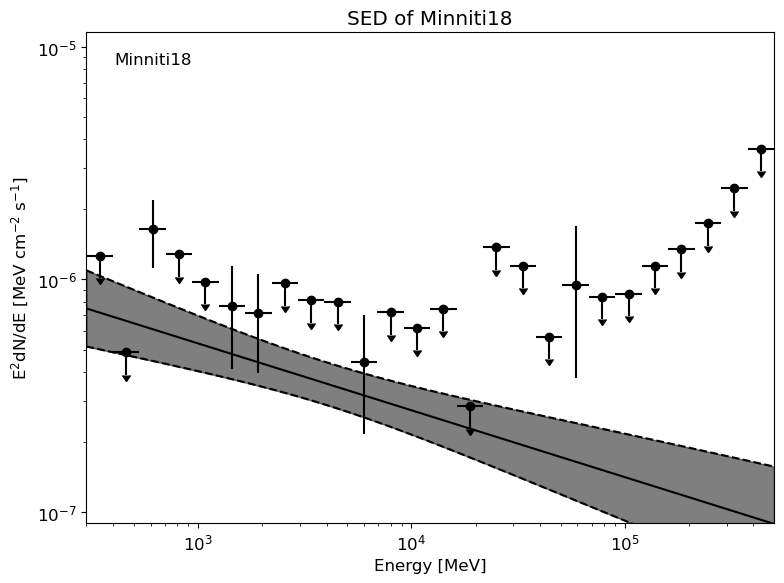

In [50]:
plt.figure(figsize=(8, 6))

plotter = SEDPlotter(sed_minniti)
plotter.plot()

plt.title("SED of Minniti18")
plt.tight_layout()
plt.show()

2026-07-26 17:59:57 INFO    GTAnalysis.sed(): Computing SED for Minniti18
2026-07-26 18:00:04 INFO    GTAnalysis._make_sed(): Fitting SED
2026-07-26 18:00:04 INFO    GTAnalysis.free_source(): Fixing parameters for galdiff               : ['Index']
2026-07-26 18:00:04 INFO    GTAnalysis.free_source(): Freeing parameters for Minniti18             : ['Prefactor']
2026-07-26 18:00:16 INFO    GTAnalysis.sed(): Finished SED
2026-07-26 18:00:21 INFO    GTAnalysis.sed(): Execution time: 23.85 s


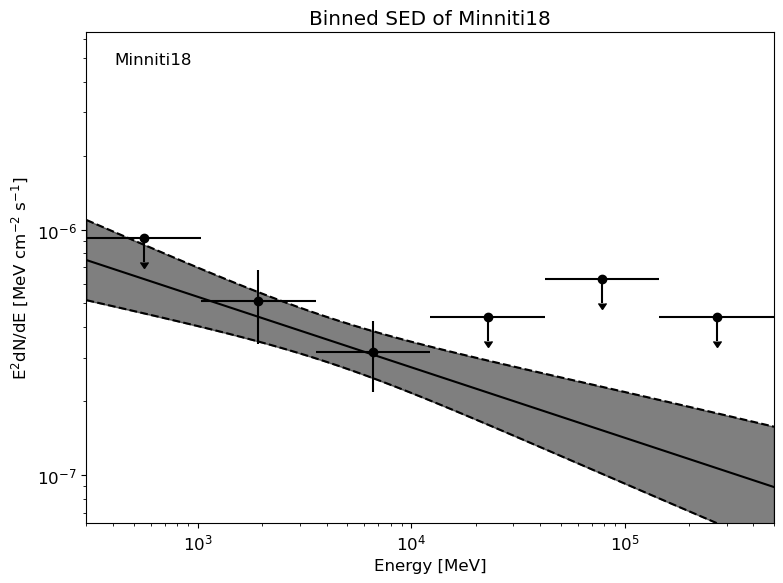

In [66]:
sed_minniti_binned = gta.sed(
    'Minniti18', 
    loge_bins=np.linspace(2.477, 5.699, 7),
    make_plots=True, 
    write_npy=True, 
    write_fits=True, 
    outfile='/Users/maomao/sfsu_research/minniti/results/standard_diffuse/seds/sed_minniti18_binned')

plt.figure(figsize=(8, 6))

plotter = SEDPlotter(sed_minniti_binned)
plotter.plot()

plt.title("Binned SED of Minniti18")
plt.tight_layout()
plt.show()

2026-07-26 18:13:23 INFO    GTAnalysis.sed(): Computing SED for Minniti18
2026-07-26 18:13:29 INFO    GTAnalysis._make_sed(): Fitting SED
2026-07-26 18:13:30 INFO    GTAnalysis.free_source(): Fixing parameters for galdiff               : ['Index']
2026-07-26 18:13:30 INFO    GTAnalysis.free_source(): Freeing parameters for Minniti18             : ['Prefactor']
2026-07-26 18:13:47 INFO    GTAnalysis.sed(): Finished SED
2026-07-26 18:13:53 INFO    GTAnalysis.sed(): Execution time: 29.93 s


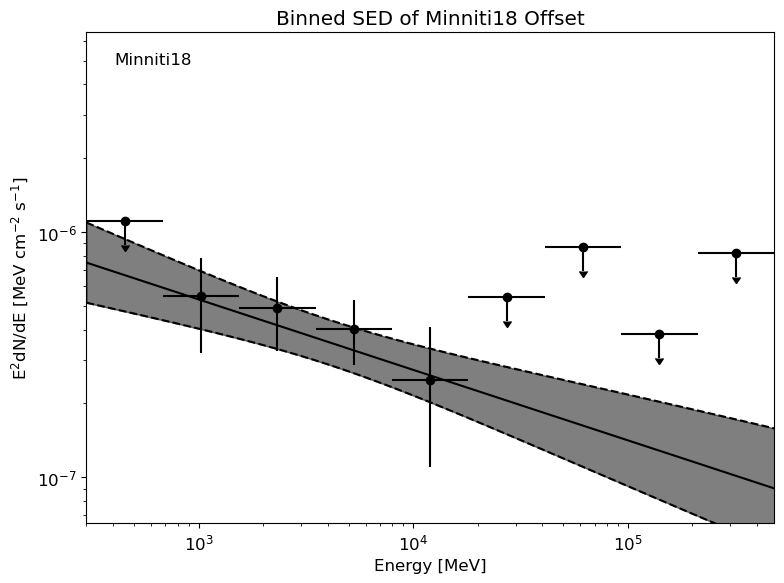

In [73]:
sed_minniti_binned_offset = gta.sed(
    'Minniti18', 
    loge_bins=np.linspace(2.477,5.681,10),
    make_plots=True, 
    write_npy=True, 
    write_fits=True, 
    outfile='/Users/maomao/sfsu_research/minniti/results/standard_diffuse/seds/sed_minniti18_binned_offset')

plt.figure(figsize=(8, 6))

plotter = SEDPlotter(sed_minniti_binned_offset)
plotter.plot()

plt.title("Binned SED of Minniti18 Offset")
plt.tight_layout()
plt.show()